# Clinical analysis of CDK4/6 mutations

In [11]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
import re
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

In [13]:
cases = pd.read_excel('Case_series_cdk_mut.xlsx').dropna(subset='mutation').reset_index(drop=True)



def extract_numbers(text):
    """Extracts all numbers from the given text."""
    return [int(i) for i in re.findall(r'\d+', text)][0]

cases['codon'] = [extract_numbers(i) for i in cases['mutation']]
cases

,Patient_ID (record ID),Tumor sample,Disease history,gene,mutation,Specific missense present in database,other relevant,Sequencing time (before vs. after ET+/=CDK4/6i),codon
0,665,P-0000015-T01-IM3,Progression very end adjuvant treatment. Tam 1...,CDK4,p.D196H,yes,"PIK3CA E545K, ESR1 p.L536H, TP53",After,196
1,2747,P-0012532-T01-IM5,"ngs (CDK) --> Adjuvant ET therapy, ongoing (~2...",CDK4,p.D84H,yes,"PIK3CA p.H1047R, TP53",before,84
2,2742,P-0016773-T01-IM6,"ngs (CDK) --> Adjuvant ET, ongoing 9 years",CDK4,p.R240Q,yes,"MSI, TMB 400",before,240
3,4022,P-0026885-T01-IM6,local recurrence after 10years --> ngs (CDK) ...,CDK4,p.E263K,no (same codon),TMB 157,before,263
4,2038,P-0030800-T01-IM6,recurrence 2 y on adjuvant ET --> ngs (CDK) --...,CDK6,p.R46Q,no (same codon),FAT1,before,46
5,4676,P-0035157-T01-IM6,"ngs (CDK) --> adjuvant Tam 5 years, no PD",CDK6,p.A259V,yes,PIK3CA p.H1047L,before,259
6,7818,P-0081718-T01-IM7,ngs (CDK) --> exemestane/palbo PFS ~16 mo -->...,CDK6,p.L105F,yes,"PIK3CA p.E545K, TP53 (both confirmed on both n...",before and post,105
7,3370,P-0018893-T01-IM6,dx mets --> ngs (CDK) --> 1L paclitaxel --> 2L...,CDK4,p.E94Q,yes,NA (19 muts),before,94
8,1601,P-0004537-T01-IM5,adjuvant anastrozole 5 mo DFS --> ngs (CDK) --...,CDK6,p.D102N,no codon matching,"TP53, NF1",NaN,102
9,1438,P-0008398-T02-IM6,ngs (no CDK) --> 1L tamoxifen 18 mo --> AI/pal...,CDK4,p.I284M,no codon matching,NaN,after,284


In [8]:
ABE_master = pd.read_csv('../../screening_data/03_LFC_FDR_tables/ABE_master_LFC_table.csv')
CBE_master = pd.read_csv('../../screening_data/03_LFC_FDR_tables/CBE_master_LFC_table.csv')

ABE_editing = pd.read_csv('../../screening_data/04_editing/ABE_editing_master.csv')
CBE_editing = pd.read_csv('../../screening_data/04_editing/CBE_editing_master.csv')

In [52]:
min_edit = 20

abe_cdk4 = ABE_editing[(ABE_editing['Gene']=='CDK4') & (ABE_editing['%Reads']>=min_edit) & (ABE_editing['Codon']!='WT')]
abe_cdk6 = ABE_editing[(ABE_editing['Gene']=='CDK6') & (ABE_editing['%Reads']>=min_edit) & (ABE_editing['Codon']!='WT')]
cbe_cdk4 = CBE_editing[(CBE_editing['Gene']=='CDK4') & (CBE_editing['%Reads']>=min_edit) & (CBE_editing['Codon']!='WT')]
cbe_cdk6 = CBE_editing[(CBE_editing['Gene']=='CDK6') & (CBE_editing['%Reads']>=min_edit) & (CBE_editing['Codon']!='WT')]


cdk4_muts = pd.concat((abe_cdk4, cbe_cdk4))
cdk6_muts = pd.concat((abe_cdk6, cbe_cdk6))


cdk4_muts['Codon'] = [int(i) for i in cdk4_muts['Codon']]
cdk6_muts['Codon'] = [int(i) for i in cdk6_muts['Codon']]

In [58]:
cdk4_cases = cases[cases['gene']=='CDK4']
cdk6_cases = cases[cases['gene']=='CDK6']

cdk4_mut_subset = cdk4_muts[cdk4_muts['Codon'].isin(list(cdk4_cases['codon']))]
cdk6_mut_subset = cdk6_muts[cdk6_muts['Codon'].isin(list(cdk6_cases['codon']))]

print(list(np.unique(cdk4_mut_subset['Codon'])))
print(sorted(list(cdk4_cases['codon'])))
print(list(np.unique(cdk6_mut_subset['Codon'])))
print(sorted(list(cdk6_cases['codon'])))

[84, 94, 162, 166, 196, 240, 263, 284]
[84, 94, 162, 166, 196, 240, 263, 284]
[18, 46, 86, 105, 168, 220, 259, 297]
[18, 46, 86, 102, 105, 168, 220, 259, 297]


In [174]:
cdk4_muts[cdk4_muts['Codon'].isin([162])]

,gRNA_id,Gene,Total_sensor_reads,HGVSp,%Reads,Codon,Top_HGVSp,Top_HGVSp_Codon,Top_HGVSp_%Reads,WT_perc,Missense_perc,Nonsense_perc,Mutation_Class_SAV,Mutation_Class_Top_HGVSp,Editor
71422,gRNA_CDK4_targ_7577,CDK4,33156,A162T,34.621185,162,A162T,162,21.284232,43.434069,54.949330,1.616600,Missense,Missense,CBE
74433,gRNA_CDK4_targ_7823,CDK4,9523,A162V,22.366901,162,A162V,162,19.909692,45.920403,51.695894,2.383703,Missense,Missense,CBE


In [175]:
CBE_master[CBE_master['gRNA_id'].isin(['gRNA_CDK4_targ_7577','gRNA_CDK4_targ_7823'])][cols].dropna()

,gRNA_id,LFC_median_RIBO_DMSO,LFC_median_PALBO_DMSO,LFC_median_ABEMA_DMSO,LFC_median_ATIRMO_DMSO,LFC_median_TAGTO_DMSO,LFC_median_INX_DMSO,FDR_RIBO_DMSO,FDR_PALBO_DMSO,FDR_ABEMA_DMSO,FDR_ATIRMO_DMSO,FDR_TAGTO_DMSO,FDR_INX_DMSO
22915,gRNA_CDK4_targ_7577,-0.110438,0.182978,-0.287882,-0.095667,-0.850908,0.057895,0.696474,0.887645,0.665289,0.778937,0.999425,0.787335
23161,gRNA_CDK4_targ_7823,-0.611627,-0.865446,-0.672970,-1.234143,-0.087290,0.114283,0.391530,0.306466,0.379188,0.264772,0.938911,0.716894


In [173]:
ABE_master[ABE_master['gRNA_id'].isin(['gRNA_CDK4_targ_7645','gRNA_CDK4_targ_7464'])][cols].dropna()

,gRNA_id,LFC_median_RIBO_DMSO,LFC_median_PALBO_DMSO,LFC_median_ABEMA_DMSO,LFC_median_ATIRMO_DMSO,LFC_median_TAGTO_DMSO,LFC_median_INX_DMSO,FDR_RIBO_DMSO,FDR_PALBO_DMSO,FDR_ABEMA_DMSO,FDR_ATIRMO_DMSO,FDR_TAGTO_DMSO,FDR_INX_DMSO
20072,gRNA_CDK4_targ_7464,-0.777566,0.578171,0.022603,1.500741,0.760567,-0.225653,0.606072,1.0,0.999999,0.702402,0.999954,0.999949
20253,gRNA_CDK4_targ_7645,1.916912,0.776205,1.255161,0.919247,1.465534,-0.036295,0.096722,1.0,0.611389,0.664943,0.999954,0.950463


In [81]:
abe_cdk4_guides = np.unique(cdk4_mut_subset[cdk4_mut_subset['Editor']=='ABE']['gRNA_id'])
cbe_cdk4_guides = np.unique(cdk4_mut_subset[cdk4_mut_subset['Editor']=='CBE']['gRNA_id'])
abe_cdk6_guides = np.unique(cdk6_mut_subset[cdk6_mut_subset['Editor']=='ABE']['gRNA_id'])
cbe_cdk6_guides = np.unique(cdk6_mut_subset[cdk6_mut_subset['Editor']=='CBE']['gRNA_id'])


cols = ['gRNA_id', 'LFC_median_RIBO_DMSO', 'LFC_median_PALBO_DMSO', 'LFC_median_ABEMA_DMSO', 'LFC_median_ATIRMO_DMSO', 'LFC_median_TAGTO_DMSO', 'LFC_median_INX_DMSO', 'FDR_RIBO_DMSO', 'FDR_PALBO_DMSO', 'FDR_ABEMA_DMSO', 'FDR_ATIRMO_DMSO', 'FDR_TAGTO_DMSO', 'FDR_INX_DMSO']
ABE_CDK4 = ABE_master[ABE_master['gRNA_id'].isin(abe_cdk4_guides)][cols].dropna()
CBE_CDK4 = CBE_master[CBE_master['gRNA_id'].isin(cbe_cdk4_guides)][cols].dropna()
ABE_CDK6 = ABE_master[ABE_master['gRNA_id'].isin(abe_cdk6_guides)][cols].dropna()
CBE_CDK6 = CBE_master[CBE_master['gRNA_id'].isin(cbe_cdk6_guides)][cols].dropna()




In [99]:
a4 = pd.merge(ABE_CDK4, cdk4_muts[cdk4_muts['Editor']=='ABE'], on='gRNA_id')
c4 = pd.merge(CBE_CDK4, cdk4_muts[cdk4_muts['Editor']=='CBE'], on='gRNA_id')
a6 = pd.merge(ABE_CDK6, cdk6_muts[cdk6_muts['Editor']=='ABE'], on='gRNA_id')
c6 = pd.merge(CBE_CDK6, cdk6_muts[cdk6_muts['Editor']=='CBE'], on='gRNA_id')

In [129]:
cdk4_full = pd.concat((a4, c4))
cdk6_full = pd.concat((a6, c6))

#then need to remove duplicate gRNAs
cdk4_filt = cdk4_full[cdk4_full['Codon'].isin(list(np.unique(cdk4_cases['codon'])))]
cdk4_filt = cdk4_filt.sort_values(by=['gRNA_id', '%Reads'], ascending=False).drop_duplicates(subset='gRNA_id')

cdk6_filt = cdk6_full[cdk6_full['Codon'].isin(list(np.unique(cdk6_cases['codon'])))]
cdk6_filt = cdk6_filt.sort_values(by=['gRNA_id', '%Reads'], ascending=False).drop_duplicates(subset='gRNA_id')

c_dict = {'ABE':'tab:purple', 'CBE':'tab:blue'}
cdk4_filt['color'] = [c_dict[i] for i in cdk4_filt['Editor']]
cdk6_filt['color'] = [c_dict[i] for i in cdk6_filt['Editor']]

In [143]:
def find_ranges(numbers):
    if not numbers:
        return []

    # Sort the list to ensure consecutive numbers are adjacent
    sorted_numbers = sorted(list(set(numbers)))  # Use set to handle duplicates

    ranges = []
    if not sorted_numbers:
        return ranges

    start_of_range = sorted_numbers[0]
    
    for i in range(1, len(sorted_numbers)):
        if sorted_numbers[i] != sorted_numbers[i-1] + 1:
            # End of current range, add it to the list
            ranges.append((start_of_range, sorted_numbers[i-1]))
            start_of_range = sorted_numbers[i] # Start a new range
    
    # Add the last range
    ranges.append((start_of_range, sorted_numbers[-1]))
    
    return ranges

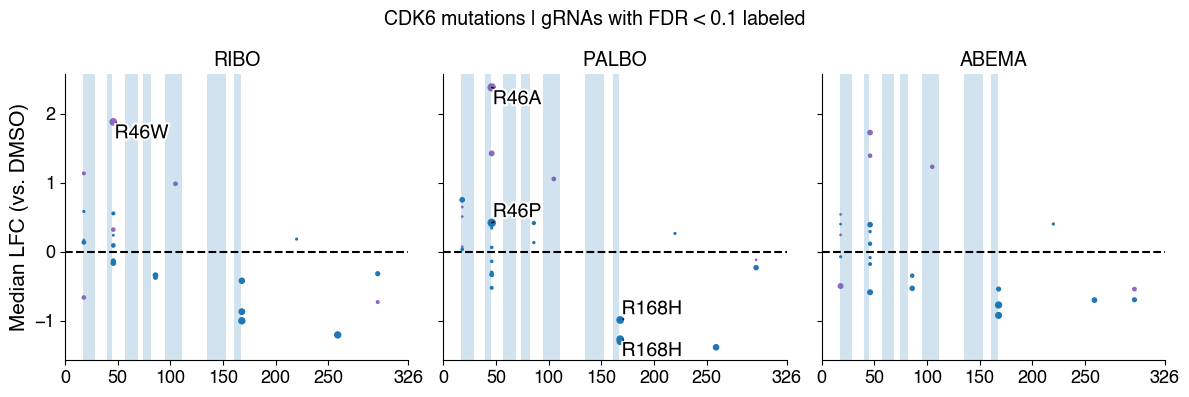

In [163]:
conditions = ['RIBO', 'PALBO', 'ABEMA']
FDR_cutoff_plot = 0.1

fig, ax = plt.subplots(1,3,figsize=(12,4), sharey=True)

for x, cond in enumerate(conditions):
    ax[x].scatter(cdk6_filt['Codon'], cdk6_filt[f'LFC_median_{cond}_DMSO'],s = 20*-np.log10(cdk6_filt[f'FDR_{cond}_DMSO'])+1, c=cdk6_filt['color'])

    bb2 = cdk6_filt[cdk6_filt[f'FDR_{cond}_DMSO']<FDR_cutoff_plot]
    t = list(bb2['HGVSp'])
    x2=list(bb2['Codon'])
    y = list(bb2[f'LFC_median_{cond}_DMSO'])

    
    texts = [ax[x].text(x2[i], y[i], t[i], fontsize=14, color='black', path_effects=[PathEffects.withStroke(linewidth=3,
                                                                                    foreground="w")]) for i in range(len(x2))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

    adjust_text(texts,only_move={'points':'xy', 'texts':'xy'}, ax=ax[x], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))

    ax[x].set_title(cond, fontsize=14)
    ax[x].set_xticks([0,50,100,150,200,250,326])
    ax[x].set_xlim(0,326)

    ax[x].spines[['right', 'top']].set_visible(False)
    ax[x].tick_params(axis='both', which='major', labelsize=13)
    ax[x].axhline(0, color='black', linestyle='dashed')

#finally, add the KLIFS pocket annotations
KLIFS = pd.read_csv('../../source_data/16_KLIFS/KLIFS_compiled.csv')
j = 'CDK6'
numbers = list(KLIFS[j].dropna())
r = find_ranges(numbers)
for a in range(3):
    for k in r:
        ax[a].axvspan(k[0],k[1], alpha=.2)

ax[0].set_ylabel('Median LFC (vs. DMSO)', fontsize=15)

fig.suptitle(f'CDK6 mutations | gRNAs with FDR < {FDR_cutoff_plot} labeled', fontsize=14)

fig.tight_layout()

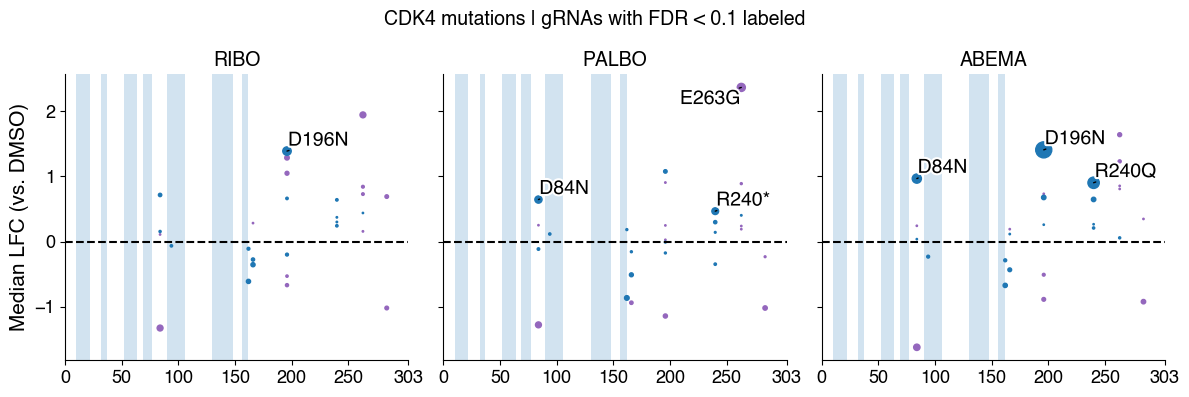

In [162]:
conditions = ['RIBO', 'PALBO', 'ABEMA']
FDR_cutoff_plot = 0.1

fig, ax = plt.subplots(1,3,figsize=(12,4), sharey=True)

for x, cond in enumerate(conditions):
    ax[x].scatter(cdk4_filt['Codon'], cdk4_filt[f'LFC_median_{cond}_DMSO'],s = 20*-np.log10(cdk4_filt[f'FDR_{cond}_DMSO'])+1, c=cdk4_filt['color'])

    bb2 = cdk4_filt[cdk4_filt[f'FDR_{cond}_DMSO']<FDR_cutoff_plot]
    t = list(bb2['HGVSp'])
    x2=list(bb2['Codon'])
    y = list(bb2[f'LFC_median_{cond}_DMSO'])

    
    texts = [ax[x].text(x2[i], y[i], t[i], fontsize=14, color='black', path_effects=[PathEffects.withStroke(linewidth=3,
                                                                                    foreground="w")]) for i in range(len(x2))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

    adjust_text(texts,only_move={'points':'xy', 'texts':'xy'}, ax=ax[x], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))

    ax[x].set_title(cond, fontsize=14)

    ax[x].set_xticks([0,50,100,150,200,250,303])
    ax[x].set_xlim(0,303)
    ax[x].spines[['right', 'top']].set_visible(False)
    ax[x].tick_params(axis='both', which='major', labelsize=13)
    ax[x].axhline(0, color='black', linestyle='dashed')
    

#finally, add the KLIFS pocket annotations
KLIFS = pd.read_csv('../../source_data/16_KLIFS/KLIFS_compiled.csv')
j = 'CDK4'
numbers = list(KLIFS[j].dropna())
r = find_ranges(numbers)
for a in range(3):
    for k in r:
        ax[a].axvspan(k[0],k[1], alpha=.2)

ax[0].set_ylabel('Median LFC (vs. DMSO)', fontsize=15)

fig.suptitle(f'CDK4 mutations | gRNAs with FDR < {FDR_cutoff_plot} labeled', fontsize=14)

fig.tight_layout()


In [183]:
cdk6_highlight = cdk6_mut_subset[cdk6_mut_subset['Codon'].isin([168, 46])]

cdk6_highlight['gRNA_id2'] = [f'{val["gRNA_id"]}_{val["Editor"]}' for i, val in cdk6_highlight.iterrows()]
cdk6_highlight

,gRNA_id,Gene,Total_sensor_reads,HGVSp,%Reads,Codon,Top_HGVSp,Top_HGVSp_Codon,Top_HGVSp_%Reads,WT_perc,Missense_perc,Nonsense_perc,Mutation_Class_SAV,Mutation_Class_Top_HGVSp,Editor,gRNA_id2
50277,gRNA_CDK6_targ_8184,CDK6,6425,R46A,20.357977,46,V47A,47,37.945525,1.307393,98.630350,0.062257,Missense,Missense,ABE,gRNA_CDK6_targ_8184_ABE
50301,gRNA_CDK6_targ_8186,CDK6,15307,R46P,21.356242,46,R46P,46,21.055726,1.404586,98.327563,0.267851,Missense,Missense,ABE,gRNA_CDK6_targ_8186_ABE
52083,gRNA_CDK6_targ_8419,CDK6,106,R46W,64.150943,46,R46W_Q48*,46,60.377358,9.433962,29.245283,61.320755,Missense,Nonsense,ABE,gRNA_CDK6_targ_8419_ABE
52092,gRNA_CDK6_targ_8420,CDK6,3767,R46W,49.031059,46,R46W,46,47.146270,14.441200,85.266791,0.292010,Missense,Missense,ABE,gRNA_CDK6_targ_8420_ABE
52102,gRNA_CDK6_targ_8422,CDK6,2648,R46W,92.220544,46,R46W,46,54.871601,0.188822,99.320242,0.490937,Missense,Missense,ABE,gRNA_CDK6_targ_8422_ABE
77423,gRNA_CDK6_targ_8100,CDK6,4221,R168H,32.267235,168,R168H,168,31.248519,32.148780,67.732765,0.118455,Missense,Missense,CBE,gRNA_CDK6_targ_8100_CBE
77434,gRNA_CDK6_targ_8101,CDK6,4725,R168H,30.116402,168,A167T,167,25.375661,5.756614,91.195767,3.047619,Missense,Missense,CBE,gRNA_CDK6_targ_8101_CBE
78493,gRNA_CDK6_targ_8186,CDK6,72084,R46Q,72.233783,46,R46Q,46,58.438766,3.422396,94.944787,1.632817,Missense,Missense,CBE,gRNA_CDK6_targ_8186_CBE
80157,gRNA_CDK6_targ_8332,CDK6,16610,R168C,44.136063,168,R168C,168,42.438290,43.383504,51.402769,5.213727,Missense,Missense,CBE,gRNA_CDK6_targ_8332_CBE
81095,gRNA_CDK6_targ_8418,CDK6,11862,R46W,28.696678,46,Q48*,48,28.123419,4.392177,23.326589,72.281234,Missense,Nonsense,CBE,gRNA_CDK6_targ_8418_CBE


# logo plots 

In [245]:
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')


SAV_ABE3 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool3.zip')
SAV_ABE3 = pd.merge(SAV_ABE3, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE3 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool3.zip')
SAV_CBE3 = pd.merge(SAV_CBE3, library[['gRNA_id', 'Gene']], on='gRNA_id')

#------also load the raw editing for each (i.e. with compound mutations) -------
ABE3 = pd.read_csv('../../screening_data/04_editing/ABE_CDK2_4_6_HGVSp.zip')
CBE3 = pd.read_csv('../../screening_data/04_editing/CBE_CDK2_4_6_HGVSp.zip')

In [246]:
data_ABE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK2_4_6_ABE_barcode_DMSO_base.csv')
data_CBE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK2_4_6_CBE_barcode_DMSO_base.csv')

condition = 'PALBO'
condition_a = condition

FDR_cutoff = 0.1
base_min = 100
max_WT = 90

#conditions = ['']

data_ABE = data_ABE.rename(columns = {f'LFC_median_ABE_{condition}':f'LFC_median_{condition}'})
data_CBE = data_CBE.rename(columns = {f'LFC_median_CBE_{condition}':f'LFC_median_{condition}'})

data_ABE['Editor']='ABE'
data_CBE['Editor'] = 'CBE'

#WT_ABE = SAV_ABE3[SAV_ABE3['HGVSp']=='WT'].reset_index(drop=True)
#WT_CBE = SAV_CBE3[SAV_CBE3['HGVSp']=='WT'].reset_index(drop=True)
#WT_ABE = WT_ABE[['gRNA_id', '%Reads']].rename(columns = {'%Reads':'WT_perc'})
#WT_CBE = WT_CBE[['gRNA_id', '%Reads']].rename(columns = {'%Reads':'WT_perc'})

#data_ABE = pd.merge(data_ABE, WT_ABE, on='gRNA_id')
#data_CBE = pd.merge(data_CBE, WT_CBE, on='gRNA_id')

data = pd.concat((data_ABE, data_CBE))

all_conditions = ['RIBO', 'ABEMA','PALBO', ]

#subset = data[(data[f'FDR_{condition}']<FDR_cutoff) & (data['classification']=='targeting') & (data['base_RAW']>=base_min) & (data['WT_perc']<=90)].sort_values(by=f'LFC_median_{condition}', ascending=False)

#subset['gRNA_id2'] = [f'{val["gRNA_id"]}_{val["Editor"]}' for i, val in subset.iterrows()]

data['gRNA_id2'] = [f'{val["gRNA_id"]}_{val["Editor"]}' for i, val in data.iterrows()]

In [247]:
subset = data[data['gRNA_id2'].isin(list(cdk6_highlight['gRNA_id2']))]
subset

,gRNA_id,Gene,classification,ABE_ABEMA_REP1,ABE_ABEMA_REP2,ABE_ABEMA_REP3,LFC_avg_ABE_ABEMA,LFC_median_ABE_ABEMA,base_RPM,base_RAW,...,FDR_CBE_INX,p_CBE_PALBO,FDR_CBE_PALBO,p_CBE_RIBO,FDR_CBE_RIBO,p_CBE_T0,FDR_CBE_T0,p_CBE_TAGTO,FDR_CBE_TAGTO,gRNA_id2
1211,gRNA_CDK6_targ_8184,CDK6,targeting,1.514225,1.391671,1.022010,1.309302,1.391671,158.768736,204.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK6_targ_8184_ABE
1213,gRNA_CDK6_targ_8186,CDK6,targeting,1.284865,1.169159,0.854826,1.102950,1.169159,808.369791,2951.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK6_targ_8186_ABE
1446,gRNA_CDK6_targ_8419,CDK6,targeting,0.379035,-0.346834,1.370430,0.467544,0.379035,1146.798795,2632.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK6_targ_8419_ABE
1447,gRNA_CDK6_targ_8420,CDK6,targeting,0.732030,-0.377965,1.303241,0.552435,0.732030,1683.338991,4825.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK6_targ_8420_ABE
1449,gRNA_CDK6_targ_8422,CDK6,targeting,1.163682,1.725676,1.903524,1.597628,1.725676,617.976773,2159.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK6_targ_8422_ABE
1127,gRNA_CDK6_targ_8100,CDK6,targeting,NaN,NaN,NaN,NaN,NaN,417.475760,2877.0,...,0.952559,0.006977,0.097036,0.018960,0.183697,0.238068,0.752607,0.156150,0.999425,gRNA_CDK6_targ_8100_CBE
1128,gRNA_CDK6_targ_8101,CDK6,targeting,NaN,NaN,NaN,NaN,NaN,250.353134,1705.0,...,0.784276,0.007206,0.097295,0.008649,0.128962,0.008127,0.312785,0.002257,0.382151,gRNA_CDK6_targ_8101_CBE
1213,gRNA_CDK6_targ_8186,CDK6,targeting,NaN,NaN,NaN,NaN,NaN,1662.493012,11524.0,...,0.644801,0.410180,0.738417,0.116495,0.399922,0.068340,0.499068,0.133126,0.999425,gRNA_CDK6_targ_8186_CBE
1359,gRNA_CDK6_targ_8332,CDK6,targeting,NaN,NaN,NaN,NaN,NaN,434.016004,3023.0,...,0.394449,0.011780,0.136632,0.034424,0.237236,0.397433,0.981642,0.432464,0.924034,gRNA_CDK6_targ_8332_CBE
1445,gRNA_CDK6_targ_8418,CDK6,targeting,NaN,NaN,NaN,NaN,NaN,721.683929,5448.0,...,0.945903,0.491605,0.796093,0.280978,0.568261,0.028234,0.388260,0.484656,0.954537,gRNA_CDK6_targ_8418_CBE


In [248]:
FDR_cutoff = 0.1

subset = subset[(subset['FDR_CBE_PALBO']<FDR_cutoff) | (subset['FDR_ABE_PALBO']<FDR_cutoff) | (subset['FDR_CBE_RIBO']<FDR_cutoff) | (subset['FDR_ABE_RIBO']<FDR_cutoff) | (subset['FDR_CBE_ABEMA']<FDR_cutoff) | (subset['FDR_ABE_ABEMA']<FDR_cutoff)]
subset = subset.sort_values(by='LFC_median_PALBO', ascending=False)

subset

,gRNA_id,Gene,classification,ABE_ABEMA_REP1,ABE_ABEMA_REP2,ABE_ABEMA_REP3,LFC_avg_ABE_ABEMA,LFC_median_ABE_ABEMA,base_RPM,base_RAW,...,FDR_CBE_INX,p_CBE_PALBO,FDR_CBE_PALBO,p_CBE_RIBO,FDR_CBE_RIBO,p_CBE_T0,FDR_CBE_T0,p_CBE_TAGTO,FDR_CBE_TAGTO,gRNA_id2
1211,gRNA_CDK6_targ_8184,CDK6,targeting,1.514225,1.391671,1.022010,1.309302,1.391671,158.768736,204.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK6_targ_8184_ABE
1449,gRNA_CDK6_targ_8422,CDK6,targeting,1.163682,1.725676,1.903524,1.597628,1.725676,617.976773,2159.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK6_targ_8422_ABE
1453,gRNA_CDK6_targ_8426,CDK6,targeting,NaN,NaN,NaN,NaN,NaN,653.802768,4781.0,...,0.445121,0.000595,0.057281,0.070320,0.855832,0.120234,0.604826,0.373533,0.885307,gRNA_CDK6_targ_8426_CBE
1127,gRNA_CDK6_targ_8100,CDK6,targeting,NaN,NaN,NaN,NaN,NaN,417.475760,2877.0,...,0.952559,0.006977,0.097036,0.018960,0.183697,0.238068,0.752607,0.156150,0.999425,gRNA_CDK6_targ_8100_CBE
1128,gRNA_CDK6_targ_8101,CDK6,targeting,NaN,NaN,NaN,NaN,NaN,250.353134,1705.0,...,0.784276,0.007206,0.097295,0.008649,0.128962,0.008127,0.312785,0.002257,0.382151,gRNA_CDK6_targ_8101_CBE


In [249]:
topx = subset

conditions = ['RIBO', 'ABEMA', 'PALBO',]
true_name = ['Ribociclib', 'Abemaciclib',  'Palbociclib',]
condition_dict = dict(zip(conditions, true_name))

condition = []
replicate = []
lfc = []
g_id = []
g_id2 = []
names = []
editor = []

for i, val in topx.iterrows():

    g = val['gRNA_id']
    #nn = val['Gene'] + ' ' + val['Top_HGVSp'] #+ f'\n({val["gRNA_id"]})'
    editor1 = val['Editor']
    

    for drug in conditions:
        d = condition_dict[drug]

        for rep in range(1,4):

            #if (f'ABE_{drug}_REP{rep}' in topx.columns) or (f'CBE_{drug}_REP{rep}' in topx.columns):
                
            if editor1=='ABE':
    
                r = f'ABE_{drug}_REP{rep}'
                l = val[r]
                
            elif editor1=='CBE':
                r = f'CBE_{drug}_REP{rep}'
                l = val[r]
       

            lfc.append(l)
            condition.append(d)
            replicate.append(rep)
            g_id.append(g)
            g_id2.append(f'{g}_{editor1}')
            editor.append(editor1)
            #names.append(nn)

plot_df = pd.DataFrame(dict(zip(['gRNA_id', 'gRNA_id2', 'Replicate', 'LFC', 'Condition', 'Editor'], [g_id, g_id2, replicate, lfc, condition, editor]))).sort_values(by='LFC', ascending=False)

In [250]:
import re
import logomaker

def extract_numbers(text):
    """Extracts all numbers from the given text."""
    return [int(i) for i in re.findall(r'\d+', text)][0]



def logo_df_maker(merge, gRNA_id, context_size, min_perc):

    gene = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]

    cdks = pd.read_csv('../../source_data/01_library_generation_files/cdks_info_updated.csv')

    cdk_prot = cdks.loc[cdks['Gene']==gene, 'Protein'].values[0]

    d4 = merge[(merge['HGVSp']!='WT') & (merge['%Reads']>=min_perc) & (merge['gRNA_id']==gRNA_id)]
    
    codons = []
    refs = []
    alts = []
    for i, val in d4.iterrows():
        h = val['HGVSp']
        c = val['%Reads']

        codon = extract_numbers(h)
        ref = h[0]
        alt = h[-1]
        codons.append(codon)
        refs.append(ref)
        alts.append(alt)

    d4['codon'] = codons
    d4['ref'] = refs
    d4['alt'] = alts

    min_cod = min(d4['codon'])
    max_cod = max(d4['codon'])

    assert cdk_prot[min_cod-1] == d4.loc[d4['codon']==min_cod, 'ref'].values[0]
    assert cdk_prot[max_cod-1] == d4.loc[d4['codon']==max_cod, 'ref'].values[0]

    start_cod = max(min_cod-context_size, 0)
    end_cod = min(max_cod +context_size, len(cdk_prot))

    codon_options = np.unique([i for i in cdk_prot[start_cod-1: end_cod]] + refs + alts)

    sequence = cdk_prot[start_cod-1: end_cod]
    seq_length = len(sequence)

    zero_array = [list(range(start_cod, end_cod+1))] + [np.zeros(seq_length) for i in range(len(codon_options))]

    logo_df = pd.DataFrame(dict(zip(['codon'] + list(codon_options), zero_array)))

    for i, val in d4.iterrows():
        cod = val['codon']
        alt = val['alt']
        perc = val['%Reads']

        logo_df.loc[logo_df['codon']==cod, alt]+=perc

    for i, val in enumerate(list(range(start_cod, end_cod+1))):
        cod = val
        aa = sequence[i]

        remaining_prob = 100 - np.sum(logo_df[logo_df['codon']==cod][codon_options].values)

        logo_df.loc[logo_df['codon']==cod, aa]+=remaining_prob

    logo_df = logo_df.set_index('codon')

    return logo_df, min_cod, max_cod, d4, sequence

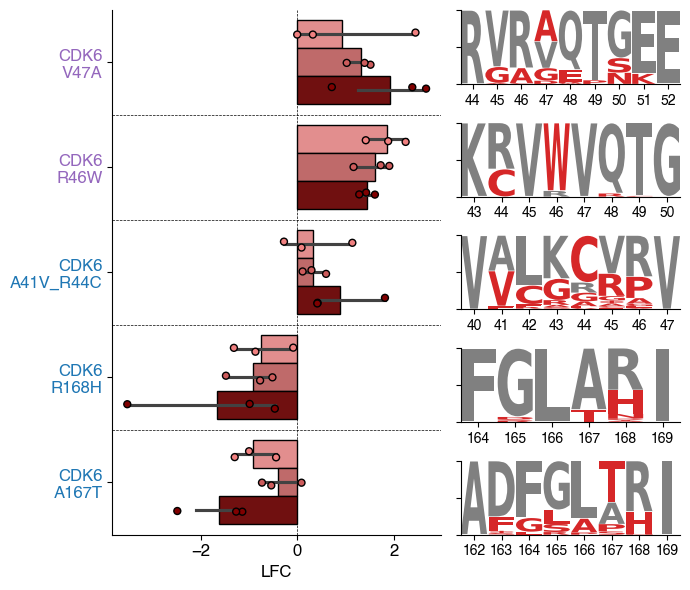

In [ ]:
from matplotlib import gridspec


fig = plt.figure(figsize=(7, 6))

num_to_plot = 5
gs = gridspec.GridSpec(num_to_plot, 2, width_ratios=[1.5, 1]) 

guides = list(subset[:num_to_plot]['gRNA_id2'])
editors= list(subset[:num_to_plot]['Editor'])


ax0 = plt.subplot(gs[:,0])

palette = ['lightcoral', 'indianred',  'maroon',]
hue_order = ['Ribociclib', 'Abemaciclib', 'Palbociclib', ]

sns.barplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, linewidth=1, edgecolor='black', legend=False, hue_order=hue_order, palette=palette)
sns.stripplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, dodge=True, linewidth=1, edgecolor='black', hue_order=hue_order, palette=palette)


top_hg = []
for i, val in enumerate(guides):

    if editors[i]=='ABE':
        merge = SAV_ABE3
        gRNA_id = val[:-4]
        context_size=1
        min_perc = 1

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = ABE3[(ABE3['gRNA_id']==gRNA_id) & (ABE3['HGVSp']!='WT') & (ABE3['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')

        
    elif editors[i]=='CBE':
        merge = SAV_CBE3
        gRNA_id = val[:-4]
        context_size=1
        min_perc = 1

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = CBE3[(CBE3['gRNA_id']==gRNA_id) & (CBE3['HGVSp']!='WT') & (CBE3['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')



ax0.set_yticklabels(top_hg)

for i, tick_label in enumerate(ax0.axes.get_yticklabels()):
    if editors[i]=='ABE':
        tick_label.set_color("tab:purple")
    if editors[i]=='CBE':
        tick_label.set_color("tab:blue")
        
ax0.tick_params(axis='both', which='major', labelsize=12)
ax0.set_ylabel('')
ax0.set_xlabel('LFC', fontsize=12)

for i in range(num_to_plot-1):
    ax0.axhline(i+0.5, linestyle='dashed', color='black', linewidth=0.5)


ax0.legend(loc='upper left')
ax0.get_legend().remove()

ax0.axvline(0, linestyle='dashed', color='black', linewidth=0.5)
ax0.spines[['right', 'top']].set_visible(False)
fig.tight_layout()
#fig.savefig('../../figures/clinical_vars_cdk6.pdf', transparent=True)
